# 🏠 House Price Prediction System

## Machine Learning Internship Project

### Objective
Predict house prices using Machine Learning algorithms.

### Algorithms Used
- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor (Final Model)

In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import joblib

## Load Dataset

In [11]:
df = pd.read_csv("../dataset/housing.csv")

df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


## Dataset Information

In [12]:
print(df.shape)
print(df.columns)
print(df.info())
print(df.describe())
print(df.isnull().sum())
print(df.duplicated().sum())

(4600, 18)
Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 

## Data Cleaning

In [13]:
df = df.drop_duplicates()

print(df["country"].unique())

df = df.drop(columns=["date","street","country"])

df.head()

['USA']


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,statezip
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline,WA 98133
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,Seattle,WA 98119
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,Kent,WA 98042
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,Bellevue,WA 98008
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,Redmond,WA 98052


## Exploratory Data Analysis

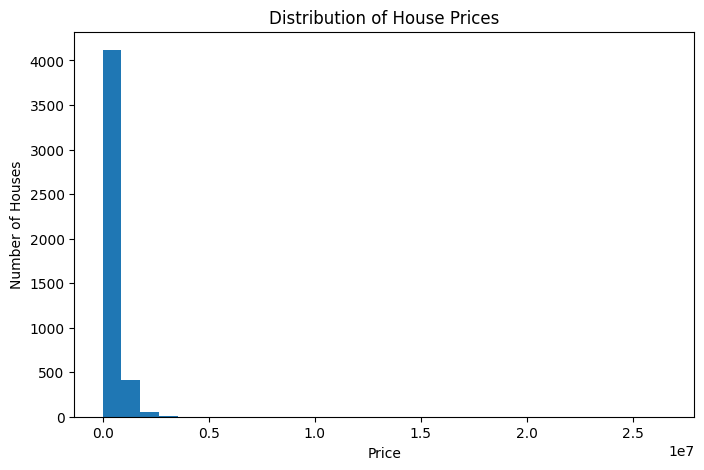

In [14]:
plt.figure(figsize=(8,5))
plt.hist(df["price"], bins=30)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Number of Houses")
plt.savefig("../images/price_distribution.png")
plt.show()

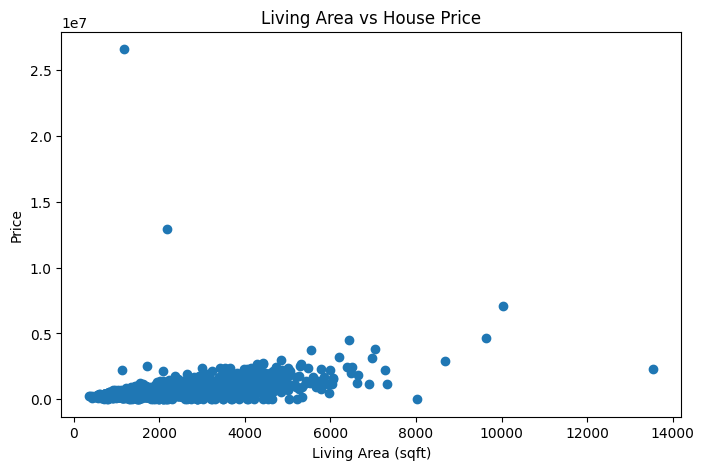

In [15]:
plt.figure(figsize=(8,5))
plt.scatter(df["sqft_living"], df["price"])
plt.title("Living Area vs House Price")
plt.xlabel("Living Area (sqft)")
plt.ylabel("Price")
plt.savefig("../images/living_area_vs_price.png")
plt.show()


Correlation with Price:
price            1.000000
sqft_living      0.430410
sqft_above       0.367570
bathrooms        0.327110
view             0.228504
sqft_basement    0.210427
bedrooms         0.200336
floors           0.151461
waterfront       0.135648
sqft_lot         0.050451
condition        0.034915
yr_built         0.021857
yr_renovated    -0.028774
Name: price, dtype: float64


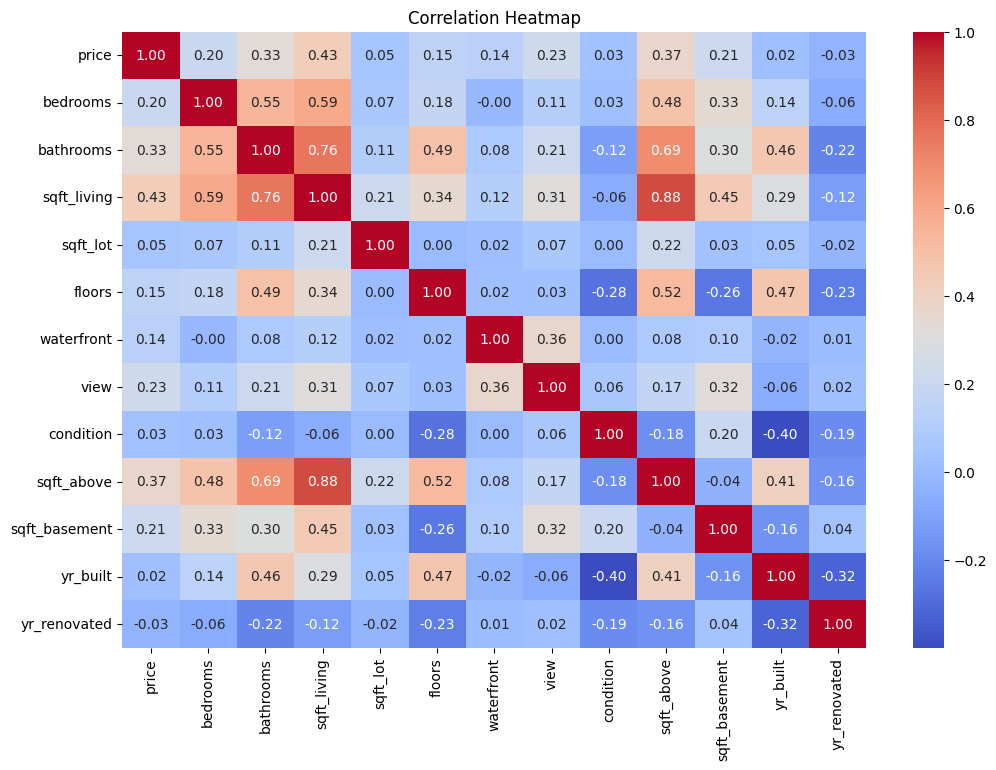

In [16]:
correlation = df.select_dtypes(include=["number"]).corr()

print("\nCorrelation with Price:")
print(correlation["price"].sort_values(ascending=False))

plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=["number"]).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.savefig("../images/correlation_heatmap.png")
plt.show()

## Label Encoding

In [17]:
encoder = LabelEncoder()

df["city"] = encoder.fit_transform(df["city"])
df["statezip"] = encoder.fit_transform(df["statezip"])

df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,statezip
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,36,62
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,35,58
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,18,26
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,3,7
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,31,31


## Feature Selection

In [18]:
X = df.drop("price",axis=1)
y = df["price"]

print(X.shape)
print(y.shape)

(4600, 14)
(4600,)


## Train Test Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (3680, 14)
Testing Features: (920, 14)
Training Target: (3680,)
Testing Target: (920,)


## Linear Regression

In [20]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)
print("First 10 Predictions:")
print(y_pred[:10])


Model Evaluation
Mean Absolute Error (MAE): 207555.78906408895
Mean Squared Error (MSE): 985909494893.8086
Root Mean Squared Error (RMSE): 992929.7532523681
R² Score: 0.033276429849473765
First 10 Predictions:
[ 305662.62547148  311782.76048487 1081407.07181464  570789.52403632
  383478.2086184   592823.07817614  460385.69429218  420037.1913733
  509439.85726871  538665.20774491]


## Decision Tree Regressor

In [21]:
dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_mae = mean_absolute_error(y_test, dt_pred)
dt_mse = mean_squared_error(y_test, dt_pred)
dt_rmse = dt_mse ** 0.5
dt_r2 = r2_score(y_test, dt_pred)

print("\nDecision Tree Evaluation")
print("MAE:", dt_mae)
print("MSE:", dt_mse)
print("RMSE:", dt_rmse)
print("R² Score:", dt_r2)


Decision Tree Evaluation
MAE: 213425.4278656228
MSE: 1020465126334.1434
RMSE: 1010180.7394393062
R² Score: -0.0006067445877544486


## Random Forest Regressor

In [22]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = rf_mse ** 0.5
rf_r2 = r2_score(y_test, rf_pred)

print("\nRandom Forest Evaluation")
print("MAE:", rf_mae)
print("MSE:", rf_mse)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)



Random Forest Evaluation
MAE: 165833.19045085175
MSE: 976122952671.2411
RMSE: 987989.3484604179
R² Score: 0.04287252470993386


## Model Comparison

In [23]:
print("-"*55)
print(f"{'Model':<20}{'MAE':<15}{'R² Score'}")
print("-"*55)
print(f"{'Linear Regression':<20}{mae:<15.2f}{r2:.4f}")
print(f"{'Decision Tree':<20}{dt_mae:<15.2f}{dt_r2:.4f}")
print(f"{'Random Forest':<20}{rf_mae:<15.2f}{rf_r2:.4f}")

-------------------------------------------------------
Model               MAE            R² Score
-------------------------------------------------------
Linear Regression   207555.79      0.0333
Decision Tree       213425.43      -0.0006
Random Forest       165833.19      0.0429


## Save Model

In [24]:
joblib.dump(rf_model, "../models/model.pkl", compress=9)

print("Model Saved Successfully")

Model Saved Successfully
